# Executable feedforward embedding diagnostics

This notebook compares the original functional emulators with frozen,
explicit feedforward realizations of their multiplier nodes. It reports:

- translation error between the two implementations;
- error against the exact polynomial recurrence;
- random-sample maximum error; and
- tensor-quadrature estimates of probability-weighted $L^2$ error.

Legendre errors use the uniform probability measure $dx/2$. Chebyshev
errors use $dx/(\pi\sqrt{1-x^2})$. Sample maxima are not certified
uniform-error bounds.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from neural_polynomial_emulation import (
    MultivariateBasisEmulator,
    emulator_complexity,
    exact_multivariate_basis,
    multi_index_set,
    to_feedforward,
)

DIMENSION = 2
ORDER = 4
INDEX_SET_TYPE = "total_degree"
FAMILIES = ("legendre", "chebyshev")
PRODUCTS = ("relu", "tanh", "repu2")
NUM_SAMPLE_POINTS = 2048
QUADRATURE_ORDER = 32
RELU_DEPTH = 12
TANH_TOLERANCE = 1e-6
DTYPE = torch.float64
SEED = 24680


## Measure-aware quadrature

Gauss--Legendre weights are divided by two for the uniform probability
measure. First-kind Gauss--Chebyshev nodes receive equal probability
weights. Tensor products give the corresponding multivariate probability
measure. Because the approximate networks are not polynomials, the reported
$L^2$ values are quadrature estimates rather than symbolic integrals.


In [2]:
def probability_quadrature(dimension, family, order):
    if family == "legendre":
        nodes, weights = np.polynomial.legendre.leggauss(order)
        weights = weights / 2.0
    elif family == "chebyshev":
        indices = np.arange(1, order + 1)
        nodes = np.cos((2 * indices - 1) * np.pi / (2 * order))
        weights = np.full(order, 1.0 / order)
    else:
        raise ValueError("unknown family")

    node_mesh = np.meshgrid(*([nodes] * dimension), indexing="ij")
    weight_mesh = np.meshgrid(*([weights] * dimension), indexing="ij")
    points = np.column_stack([values.ravel() for values in node_mesh])
    product_weights = np.ones_like(weight_mesh[0])
    for values in weight_mesh:
        product_weights *= values
    return points, product_weights.ravel()


def probability_l2_errors(error, weights):
    column_errors = np.sqrt(np.sum(weights[:, None] * error**2, axis=0))
    return (
        float(np.sqrt(np.mean(column_errors**2))),
        float(np.max(column_errors)),
    )


In [3]:
rng = np.random.default_rng(SEED)
sample_points = rng.uniform(
    -1.0, 1.0, size=(NUM_SAMPLE_POINTS, DIMENSION)
)
sample_tensor = torch.as_tensor(sample_points, dtype=DTYPE)
multi_index = multi_index_set(DIMENSION, ORDER, INDEX_SET_TYPE)
rows = []

for family in FAMILIES:
    sample_exact = exact_multivariate_basis(
        sample_points, multi_index, family=family
    )
    quadrature_points, quadrature_weights = probability_quadrature(
        DIMENSION, family, QUADRATURE_ORDER
    )
    quadrature_tensor = torch.as_tensor(quadrature_points, dtype=DTYPE)
    quadrature_exact = exact_multivariate_basis(
        quadrature_points, multi_index, family=family
    )

    for product in PRODUCTS:
        functional = MultivariateBasisEmulator(
            multi_index,
            family=family,
            product=product,
            num_layers=RELU_DEPTH,
            tanh_tolerance=TANH_TOLERANCE,
        ).to(dtype=DTYPE)
        embedded = to_feedforward(functional, dtype=DTYPE)
        with torch.no_grad():
            functional_sample = functional(sample_tensor).cpu().numpy()
            embedded_sample = embedded(sample_tensor).cpu().numpy()
            functional_quadrature = functional(quadrature_tensor).cpu().numpy()
            embedded_quadrature = embedded(quadrature_tensor).cpu().numpy()

        functional_l2, functional_max_column_l2 = probability_l2_errors(
            functional_quadrature - quadrature_exact, quadrature_weights
        )
        embedded_l2, embedded_max_column_l2 = probability_l2_errors(
            embedded_quadrature - quadrature_exact, quadrature_weights
        )
        translation_l2, _ = probability_l2_errors(
            embedded_quadrature - functional_quadrature, quadrature_weights
        )
        counts = emulator_complexity(embedded)
        actual_total = sum(parameter.numel() for parameter in embedded.parameters())
        actual_nonzero = sum(
            int(torch.count_nonzero(parameter).item())
            for parameter in embedded.parameters()
        )
        assert counts["total_parameters"] == actual_total
        assert counts["nonzero_parameters"] == actual_nonzero
        rows.append(
            {
                "family": family,
                "product": product,
                "translation_sample_max": float(
                    np.max(np.abs(embedded_sample - functional_sample))
                ),
                "functional_sample_max": float(
                    np.max(np.abs(functional_sample - sample_exact))
                ),
                "embedded_sample_max": float(
                    np.max(np.abs(embedded_sample - sample_exact))
                ),
                "translation_probability_l2": translation_l2,
                "functional_probability_l2": functional_l2,
                "embedded_probability_l2": embedded_l2,
                "functional_max_column_l2": functional_max_column_l2,
                "embedded_max_column_l2": embedded_max_column_l2,
                **counts,
            }
        )

comparison = pd.DataFrame(rows)
comparison


,family,product,translation_sample_max,functional_sample_max,embedded_sample_max,translation_probability_l2,functional_probability_l2,embedded_probability_l2,functional_max_column_l2,embedded_max_column_l2,product_nodes,relu_product_nodes,tanh_product_nodes,repu2_product_nodes,activation_units_per_sample,total_parameters,nonzero_parameters,trainable_parameters,buffer_scalars
0,legendre,relu,1.798561e-13,1.082932e-04,1.082932e-04,1.506503e-14,1.588084e-05,1.588084e-05,4.268681e-05,4.268681e-05,18,18,0,0,2592,31830,9550,0,60
1,legendre,tanh,3.590983e-11,1.445326e-06,1.445326e-06,4.211260e-13,7.762870e-08,7.762870e-08,1.481297e-07,1.481297e-07,18,0,18,0,108,798,442,0,60
2,legendre,repu2,5.329071e-15,1.243450e-14,1.243450e-14,4.916288e-16,1.467987e-15,1.417091e-15,3.481805e-15,3.481805e-15,18,0,0,18,72,366,262,0,60
3,chebyshev,relu,1.758593e-13,8.547186e-05,8.547186e-05,1.726333e-14,1.364621e-05,1.364621e-05,3.673337e-05,3.673337e-05,18,18,0,0,2592,31830,9550,0,60
4,chebyshev,tanh,1.386469e-11,6.665571e-07,6.665571e-07,3.418716e-13,1.376717e-07,1.376717e-07,2.210005e-07,2.210004e-07,18,0,18,0,108,798,442,0,60
5,chebyshev,repu2,4.218847e-15,8.215650e-15,8.215650e-15,3.857787e-16,6.922260e-16,7.361760e-16,1.411686e-15,1.411686e-15,18,0,0,18,72,366,262,0,60


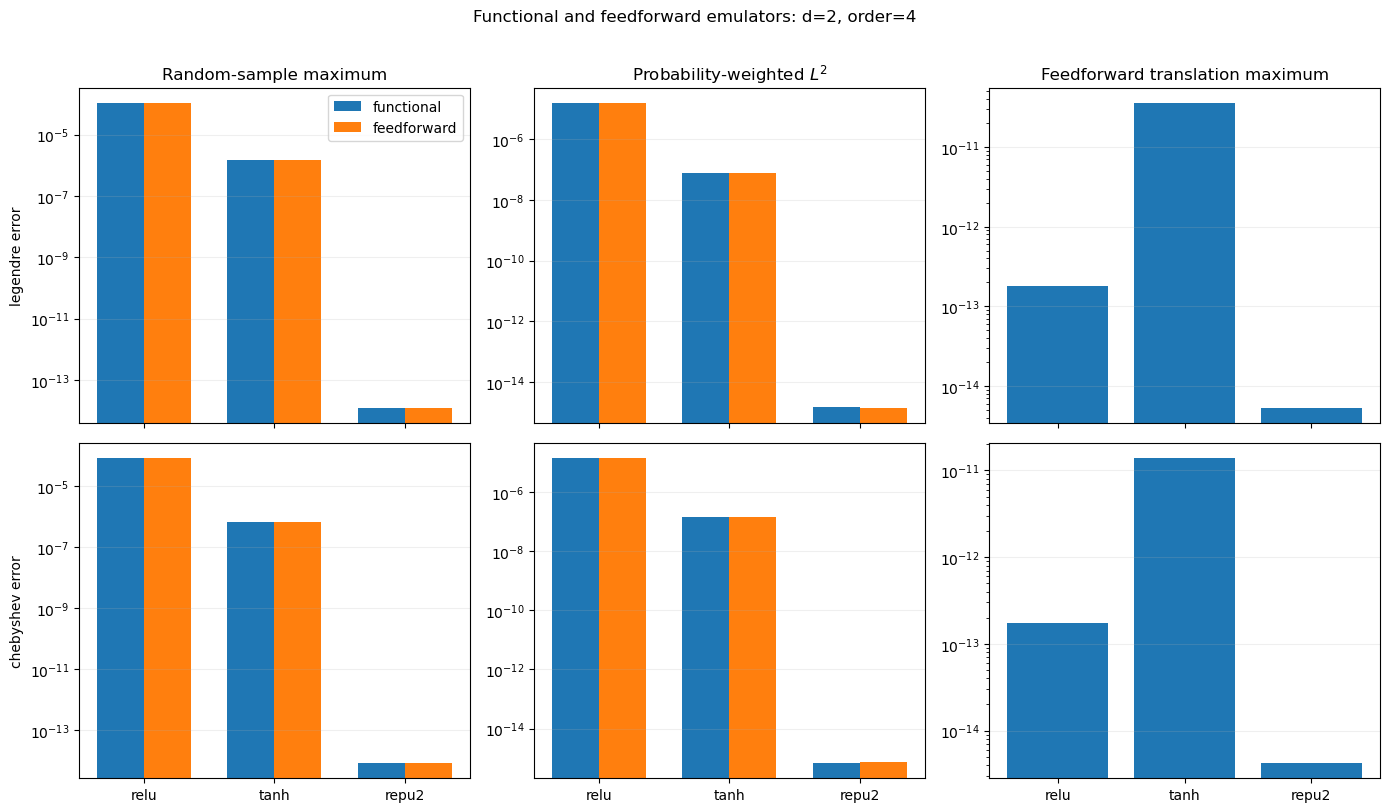

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex="col")
x = np.arange(len(PRODUCTS))
width = 0.36
for row, family in enumerate(FAMILIES):
    subset = comparison.set_index(["family", "product"]).loc[family]
    subset = subset.loc[list(PRODUCTS)]
    axes[row, 0].bar(
        x - width / 2,
        np.maximum(subset["functional_sample_max"], 1e-18),
        width,
        label="functional",
    )
    axes[row, 0].bar(
        x + width / 2,
        np.maximum(subset["embedded_sample_max"], 1e-18),
        width,
        label="feedforward",
    )
    axes[row, 1].bar(
        x - width / 2,
        np.maximum(subset["functional_probability_l2"], 1e-18),
        width,
    )
    axes[row, 1].bar(
        x + width / 2,
        np.maximum(subset["embedded_probability_l2"], 1e-18),
        width,
    )
    axes[row, 2].bar(
        x, np.maximum(subset["translation_sample_max"], 1e-18)
    )
    axes[row, 0].set_ylabel(f"{family} error")
    for ax in axes[row]:
        ax.set_yscale("log")
        ax.grid(axis="y", alpha=0.2)
        ax.set_xticks(x, PRODUCTS)
axes[0, 0].set_title("Random-sample maximum")
axes[0, 1].set_title("Probability-weighted $L^2$")
axes[0, 2].set_title("Feedforward translation maximum")
axes[0, 0].legend()
fig.suptitle(
    f"Functional and feedforward emulators: d={DIMENSION}, order={ORDER}",
    y=1.01,
)
fig.tight_layout()
plt.show()


The translation columns isolate changes caused by evaluating explicit
linear layers instead of the original algebraic expressions. They should
remain near floating-point roundoff relative to the emulation errors. The
materialized parameters are frozen; setting them trainable would define a
different learned model and would no longer be the fixed analytic
construction.
